In [1]:
!pip install yfinance prophet

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------------------- -------------- 1.0/1.6 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 4.7 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/12.1 MB 3.6 MB/s eta 0:00:04
   ------ --------------------------------- 2.1/12.1 MB 3.4 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.1 MB 3.7 MB/s eta 0:00:03
   ------------ --------------------------- 3.9/12.1 MB 3.9 MB/s eta 0:00:03
   ----------------- ---------------------- 5.2/12.1 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/12.1 MB 4.2 MB/s eta 0:00:02

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [3]:
!pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/332.0 MB 3.1 MB/s eta 0:01:48
   ---------------------------------------- 1.6/332.0 MB 4.3 MB/s eta 0:01:18
   ---------------------------------------- 1.8/332.0 MB 3.9 MB/s eta 0:01:24
   ---------------------------------------- 2.1/332.0 MB 2.9 MB/s eta 0:01:56
   ---------------------------------------- 2.4/332.0 MB 2.3 MB/s eta 0:02:22
   ---------------------------------------- 2.4/332.0 MB 2.3 MB/s eta 0:02:22
   ---------------------------------------- 2.6/332.0 MB 1.7 MB/s eta 0:03:10
   ---------------------------------------- 2.9/332.0 MB 1.7 MB/s eta 0:03:16
   ---------------------------------------- 3.1/332.0 MB 1.6 MB/s eta 0:03:21
   ---------------------------------------- 3.4/332.0 MB 1.6 MB/s eta 0:03:31
   ---------------------------------------- 3.7/332.0 MB 1.5 MB/s eta 0:03:38
   ---------------------------------------- 3.9/332.0 MB 1.5 MB/s eta 0

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [5]:
stock = yf.download("AAPL", start="2018-01-01", end="2024-01-01")

data = stock[['Close']].reset_index()
data.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [6]:
data.head()

Price,Date,Close
Ticker,,AAPL
0,2018-01-02,40.304176
1,2018-01-03,40.297165
2,2018-01-04,40.484337
3,2018-01-05,40.945263
4,2018-01-08,40.793179


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   (Date, )       1509 non-null   datetime64[ns]
 1   (Close, AAPL)  1509 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 23.7 KB


In [8]:
data.columns = ['Date', 'Close']
data.head()

,Date,Close
0,2018-01-02,40.304176
1,2018-01-03,40.297165
2,2018-01-04,40.484337
3,2018-01-05,40.945263
4,2018-01-08,40.793179


In [9]:
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

#### prophet model

In [10]:
#Format for Prophet
prophet_train = train.rename(columns={"Date":"ds","Close":"y"})

In [11]:
#Train prophet
model_prophet = Prophet()
model_prophet.fit(prophet_train)

21:34:50 - cmdstanpy - INFO - Chain [1] start processing
21:34:52 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
#forecast for test period
future = model_prophet.make_future_dataframe(periods=len(test))
forecast = model_prophet.predict(future)

prophet_pred = forecast['yhat'][-len(test):].values

#### LSTM Model

In [13]:
#Scale Data
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data[['Close']])

In [14]:
#Create Sequences (60 days window)
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset)-time_step):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, 60)

In [15]:
#split for LSTM
X_train = X[:train_size-60]
X_test = X[train_size-60:]

y_train = y[:train_size-60]
y_test = y[train_size-60:]

In [16]:
#Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [17]:
#Build LSTM Model
model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(50))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

C:\Users\neuherbs\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
#Train LSTM
model_lstm.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.0282
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0036 
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0038  
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0031  
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0032  
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0028
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0028
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0025
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0024  
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0025  
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0024
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0024    
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0023 
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0023
Epoch 15/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - l

In [19]:
#Predict
lstm_pred = model_lstm.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step 


#### ENSEMBLE MODEL

In [20]:
#Make Equal Length
prophet_pred = prophet_pred[:len(lstm_pred)]
actual = test['Close'].values[:len(lstm_pred)]

In [22]:
#Weighted Average (Better)
w1 = 0.4
w2 = 0.6

ensemble_pred = w1 * prophet_pred + w2 * lstm_pred.flatten()

#### Evaluation

In [24]:
def evaluate(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return rmse, mae, mape

print("Prophet:", evaluate(actual, prophet_pred))
print("LSTM:", evaluate(actual, lstm_pred.flatten()))
print("Ensemble:", evaluate(actual, ensemble_pred))

Prophet: (np.float64(25.457568460861744), 22.45653861861272, np.float64(13.303338172247436))
LSTM: (np.float64(4.954266637076792), 3.854047232116295, np.float64(2.425892521273155))
Ensemble: (np.float64(11.554978824241243), 9.923964046142196, np.float64(5.944812701051718))


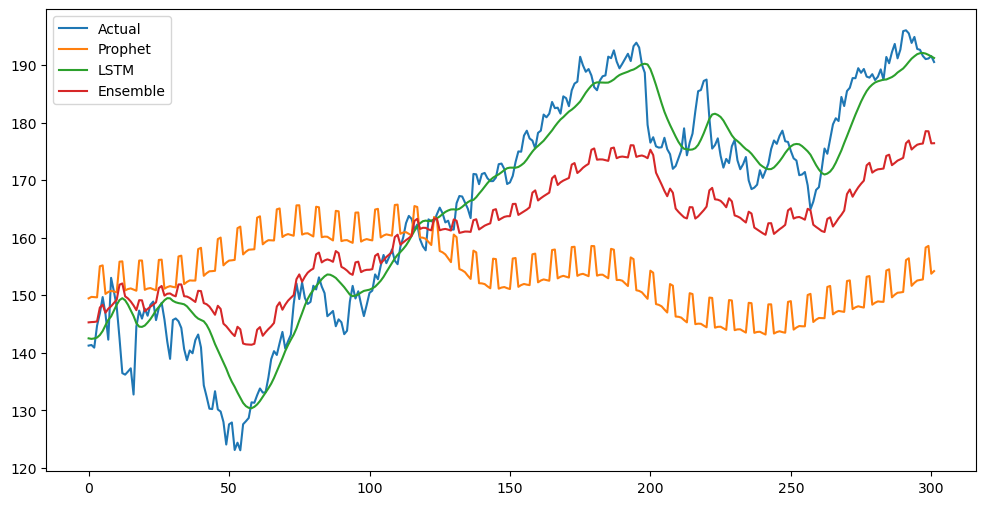

In [25]:
#Plot Results
plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual")
plt.plot(prophet_pred, label="Prophet")
plt.plot(lstm_pred, label="LSTM")
plt.plot(ensemble_pred, label="Ensemble")

plt.legend()
plt.show()

#### Multi-Step Future Forecast (Next 7 Days)

In [26]:
future_7 = model_prophet.make_future_dataframe(periods=7)
forecast_7 = model_prophet.predict(future_7)

print(forecast_7[['ds','yhat']].tail(7))

             ds        yhat
1207 2022-10-18  149.453930
1208 2022-10-19  149.717853
1209 2022-10-20  149.669672
1210 2022-10-21  149.637428
1211 2022-10-22  155.045574
1212 2022-10-23  155.197836
1213 2022-10-24  150.235775


#### LSTM Recursive Forecast

In [27]:
last_60 = scaled_data[-60:]
future_predictions = []

current_batch = last_60.reshape(1,60,1)

for i in range(7):
    next_pred = model_lstm.predict(current_batch)[0]
    future_predictions.append(next_pred[0])
    current_batch = np.append(current_batch[:,1:,:],[[next_pred]],axis=1)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))
print(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[190.94576]
 [190.6577 ]
 [190.38057]
 [190.11295]
 [189.85373]
 [189.60205]
 [189.35739]]


In [ ]:
jupyter nbconvert --to script stock_pred.ipynb
